# 04. 다중회귀 — 점진적 변수 추가 모델 & 조정지표

| 모델 | 추가 변수 그룹 |
|------|---------------|
| M0 (기본) | living_pop, food_accom + 연도 FE |
| M1 | + 주거 특성 (elderly_ratio, single_hh_ratio) |
| M2 | + 상업/활동 (emp_per_pop) |
| M3 | + 관광/방문/상권 밀집 (day_night_ratio) |
| M4 | + 소비 (sales_per_pop) |
| M_full | M0~M4 전체 통합 |
| M5 | VIF 기반 자동 제거 (M4 출발) |
| M6 | M5 + 물류/도소매 (강서구 이상치 보완) |
| M7 | M6 + 외국인비율/지하철인구수/대형사업체 (용산구 이상치 보완) |

**종속변수**: log(waste_total)  /  **모든 연속변수 표준화**  /  **패널 n=100**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE  = Path('../../data')
PROC  = BASE / 'processed'
FINAL = BASE / 'final'

COL_KR = {
    'living_pop_std':          '생활인구 일평균',
    'food_accom_std':          '음식숙박업 수',
    'elderly_std':             '고령인구 비율',
    'single_hh_std':           '1인가구 비율',
    'emp_per_pop_std':         '종사자/인구',
    'day_night_std':           '주야간 인구비',
    'sales_per_pop_std':       '1인당 매출',
    'transport_per_pop_std':   '운수업 사업체/인구',
    'retail_per_pop_std':      '도소매업 사업체/인구',
    'foreigner_ratio_std':     '외국인 생활인구 비율',
    'subway_per_pop_std':      '지하철 승하차인원/인구',
    'large_biz_per_pop_std':   '대형사업체(100인+)/인구',
}
print('설정 완료')

설정 완료


## 1. 데이터 로드 및 변수 파생

In [ ]:
def load_year_all(path):
    return pd.read_csv(path)

# eda_master (기본 변수)
df = pd.read_csv(FINAL / 'eda_master_v2_by_gu_year.csv', encoding='utf-8-sig')

# 1인가구 비율
df_hh = load_year_all(PROC / 'population' / 'household_by_gu_year.csv')
df = df.merge(
    df_hh[['year', 'gu', 'single_hh_ratio']],
    on=['year', 'gu'],
    how='left'
)

# 종사자 수 + 물류(운수업) + 도소매업
df_biz = load_year_all(PROC / 'business' / 'business_by_industry_gu_year.csv')
df = df.merge(
    df_biz[['year', 'gu', 'emp_total', 'transport_biz', 'retail_biz']],
    on=['year', 'gu'],
    how='left'
)

# 매출
df_sale = load_year_all(PROC / 'business' / 'sales_by_gu_year.csv')
df = df.merge(
    df_sale[['year', 'gu', 'annual_sales']],
    on=['year', 'gu'],
    how='left'
)

# 외국인 생활인구
df_lp = load_year_all(PROC / 'living_population' / 'living_pop_merged_by_gu_year.csv')
df = df.merge(
    df_lp[['year', 'gu', 'foreigner_lp_daily_avg']],
    on=['year', 'gu'],
    how='left'
)

# 실제 지하철 승하차 인원
df_subway = load_year_all(PROC / 'subway' / 'subway_gu_year_2020_2023.csv')

df = df.merge(
    df_subway[[
        'year', 'gu',
        'subway_boarding_total',
        'subway_alighting_total',
        'subway_passenger_total',
        'subway_station_count'
    ]],
    on=['year', 'gu'],
    how='left'
)

subway_cols = [
    'subway_boarding_total',
    'subway_alighting_total',
    'subway_passenger_total',
    'subway_station_count'
]

df[subway_cols] = df[subway_cols].fillna(0)

# 대형사업체(종사자 100인 이상) proxy
df_sz = load_year_all(PROC / 'business' / 'business_by_size_gu_year.csv')
df_sz['large_biz'] = df_sz['s100_299_biz'] + df_sz['s1000plus_biz']

df = df.merge(
    df_sz[['year', 'gu', 'large_biz']],
    on=['year', 'gu'],
    how='left'
)

# 파생변수
df['log_waste']          = np.log(df['waste_total'])
df['emp_per_pop']        = df['emp_total']              / df['total_pop']
df['sales_per_pop']      = df['annual_sales']           / df['total_pop']
df['transport_per_pop']  = df['transport_biz']          / df['total_pop']
df['retail_per_pop']     = df['retail_biz']             / df['total_pop']
df['foreigner_ratio']    = df['foreigner_lp_daily_avg'] / df['living_pop_daily_avg']

# 지하철 변수: 실제 승하차 인원 기반
df['subway_passenger_per_pop'] = df['subway_passenger_total'] / df['total_pop']
df['log_subway_passenger'] = np.log1p(df['subway_passenger_total'])
df['log_subway_passenger_per_pop'] = np.log1p(df['subway_passenger_per_pop'])


# 이제 subway_per_pop은 '지하철역 수/인구'가 아니라 '지하철 승하차인원/인구'
df['subway_per_pop'] = df['subway_passenger_per_pop']

df['large_biz_per_pop'] = df['large_biz'] / df['total_pop']

print('shape:', df.shape)
print('연도:', sorted(df['year'].unique()))

check_cols = [
    'log_waste',
    'living_pop_daily_avg',
    'food_accom_biz',
    'elderly_ratio',
    'single_hh_ratio',
    'emp_per_pop',
    'day_night_ratio',
    'sales_per_pop',
    'transport_per_pop',
    'retail_per_pop',
    'foreigner_ratio',
    'subway_passenger_total',
    'subway_passenger_per_pop',
    'log_subway_passenger',
    'large_biz_per_pop'
]

missing = df[check_cols].isnull().sum()
print('결측:\n', missing[missing > 0])

shape: (100, 38)
연도: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
결측:
 Series([], dtype: int64)


## 2. 연속변수 표준화

In [ ]:
RAW_VARS = [
    ('living_pop_daily_avg', 'living_pop_std'),
    ('food_accom_biz',       'food_accom_std'),
    ('elderly_ratio',        'elderly_std'),
    ('single_hh_ratio',      'single_hh_std'),
    ('emp_per_pop',          'emp_per_pop_std'),
    ('day_night_ratio',      'day_night_std'),
    ('sales_per_pop',        'sales_per_pop_std'),
    ('transport_per_pop',    'transport_per_pop_std'),
    ('retail_per_pop',       'retail_per_pop_std'),
    ('foreigner_ratio',      'foreigner_ratio_std'),
    ('subway_per_pop',       'subway_per_pop_std'),
    ('large_biz_per_pop',    'large_biz_per_pop_std'),
]

for raw, std in RAW_VARS:
    scaler = StandardScaler()
    df[std] = scaler.fit_transform(df[[raw]])

STD_VARS = [s for _, s in RAW_VARS]
print('표준화 완료:', STD_VARS)
df[STD_VARS].describe().round(3)

표준화 완료: ['living_pop_std', 'food_accom_std', 'elderly_std', 'single_hh_std', 'emp_per_pop_std', 'day_night_std', 'sales_per_pop_std', 'transport_per_pop_std', 'retail_per_pop_std', 'foreigner_ratio_std', 'subway_per_pop_std', 'large_biz_per_pop_std']


,living_pop_std,food_accom_std,elderly_std,single_hh_std,emp_per_pop_std,day_night_std,sales_per_pop_std,transport_per_pop_std,retail_per_pop_std,foreigner_ratio_std,subway_per_pop_std,large_biz_per_pop_std
count,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000
mean,0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000
std,1.005,1.005,1.005,1.005,1.005,1.005,1.005,1.005,1.005,1.005,1.005,1.005
min,-1.434,-1.524,-1.718,-2.064,-0.743,-0.927,-0.972,-0.565,-0.741,-1.268,-0.664,-0.745
25%,-0.546,-0.733,-0.683,-0.742,-0.658,-0.679,-0.707,-0.469,-0.522,-0.967,-0.485,-0.665
50%,-0.230,-0.167,-0.092,0.042,-0.442,-0.348,-0.482,-0.320,-0.331,-0.083,-0.336,-0.517
75%,0.439,0.682,0.539,0.712,0.090,0.325,0.390,-0.025,0.057,0.801,-0.011,0.157
max,2.892,2.756,3.216,2.751,3.946,3.697,3.535,4.893,4.569,1.875,4.924,3.768


## 3. 모델 피팅 헬퍼 함수

In [ ]:
def calc_vif(df_, vars_):
    X = df_[vars_].dropna().values.astype(float)
    X = (X - X.mean(0)) / (X.std(0) + 1e-10)
    vif_vals = []
    for i in range(X.shape[1]):
        y_ = X[:, i]
        X_ = np.column_stack([np.ones(len(y_)), np.delete(X, i, axis=1)])
        c, *_ = np.linalg.lstsq(X_, y_, rcond=None)
        ss_res = np.sum((y_ - X_ @ c) ** 2)
        ss_tot = np.sum((y_ - y_.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vif_vals.append(round(1 / (1 - r2) if r2 < 1 else np.inf, 2))
    return pd.DataFrame({
        '변수': [COL_KR.get(v, v) for v in vars_],
        'VIF':  vif_vals,
        '판정': ['⚠>10' if v > 10 else ('△5~10' if v > 5 else '✓<5') for v in vif_vals]
    })

def fit_model(label, cont_vars, df_=df):
    formula = 'log_waste ~ ' + ' + '.join(cont_vars) + ' + C(year)'
    model   = smf.ols(formula, data=df_).fit()

    sep = '=' * 55
    print(sep)
    print(' ' + label)
    print(sep)
    print('  R²=' + f'{model.rsquared:.4f}' +
          '  Adj R²=' + f'{model.rsquared_adj:.4f}' +
          '  F p=' + f'{model.f_pvalue:.3e}' +
          '  CondNum=' + f'{model.condition_number:.1f}')
    print()

    for v in cont_vars:
        c = model.params.get(v, np.nan)
        p = model.pvalues.get(v, np.nan)
        star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        name = COL_KR.get(v, v)
        print(f'  {name:22s}  coef={c:+.4f}  p={p:.4f}  {star}')
    print()

    vif = calc_vif(df_, cont_vars)
    print(vif.to_string(index=False))
    print()

    return model

print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


## 4. M0 — 기본 모델

In [ ]:
VARS_M0 = ['living_pop_std', 'food_accom_std']
m0 = fit_model('M0: 기본 (생활인구 + 음식숙박업)', VARS_M0)

 M0: 기본 (생활인구 + 음식숙박업)
  R²=0.5801  Adj R²=0.5578  F p=2.200e-16  CondNum=5.5

  생활인구 일평균                coef=+0.2205  p=0.0000  ***
  음식숙박업 수                 coef=+0.1117  p=0.0005  ***

      변수  VIF  판정
생활인구 일평균  1.4 ✓<5
 음식숙박업 수  1.4 ✓<5



## 5. M1 — M0 + 주거 특성 (elderly_ratio, single_hh_ratio)

In [ ]:
VARS_M1 = VARS_M0 + ['elderly_std', 'single_hh_std']
m1 = fit_model('M1: M0 + 주거 특성 (고령비율, 1인가구비율)', VARS_M1)

 M1: M0 + 주거 특성 (고령비율, 1인가구비율)
  R²=0.6410  Adj R²=0.6137  F p=5.507e-18  CondNum=7.1

  생활인구 일평균                coef=+0.1977  p=0.0000  ***
  음식숙박업 수                 coef=+0.1613  p=0.0000  ***
  고령인구 비율                 coef=-0.0572  p=0.1021  n.s.
  1인가구 비율                 coef=+0.0940  p=0.0015  **

      변수  VIF  판정
생활인구 일평균 2.19 ✓<5
 음식숙박업 수 1.67 ✓<5
 고령인구 비율 1.55 ✓<5
 1인가구 비율 1.32 ✓<5



## 6. M2 — M1 + 상업/활동 (emp_per_pop)

In [ ]:
VARS_M2 = VARS_M1 + ['emp_per_pop_std']
m2 = fit_model('M2: M1 + 상업/활동 (종사자/인구)', VARS_M2)

 M2: M1 + 상업/활동 (종사자/인구)
  R²=0.6674  Adj R²=0.6381  F p=9.714e-19  CondNum=7.3

  생활인구 일평균                coef=+0.1827  p=0.0000  ***
  음식숙박업 수                 coef=+0.1857  p=0.0000  ***
  고령인구 비율                 coef=-0.0575  p=0.0900  n.s.
  1인가구 비율                 coef=+0.0791  p=0.0065  **
  종사자/인구                  coef=+0.0693  p=0.0086  **

      변수  VIF  판정
생활인구 일평균 2.25 ✓<5
 음식숙박업 수 1.82 ✓<5
 고령인구 비율 1.55 ✓<5
 1인가구 비율 1.38 ✓<5
  종사자/인구 1.20 ✓<5



## 7. M3 — M2 + 관광/방문/상권 밀집 (day_night_ratio)

In [ ]:
VARS_M3 = VARS_M2 + ['day_night_std']
m3 = fit_model('M3: M2 + 관광/방문 (주야간인구비)', VARS_M3)

 M3: M2 + 관광/방문 (주야간인구비)
  R²=0.6791  Adj R²=0.6470  F p=1.016e-18  CondNum=14.3

  생활인구 일평균                coef=+0.1793  p=0.0000  ***
  음식숙박업 수                 coef=+0.2188  p=0.0000  ***
  고령인구 비율                 coef=-0.0425  p=0.2164  n.s.
  1인가구 비율                 coef=+0.0912  p=0.0021  **
  종사자/인구                  coef=-0.1820  p=0.1994  n.s.
  주야간 인구비                 coef=+0.2643  p=0.0729  n.s.

      변수   VIF   판정
생활인구 일평균  2.28  ✓<5
 음식숙박업 수  2.34  ✓<5
 고령인구 비율  1.57  ✓<5
 1인가구 비율  1.42  ✓<5
  종사자/인구 34.40 ⚠>10
 주야간 인구비 36.64 ⚠>10



## 8. M4 — M3 + 소비 (sales_per_pop)

In [ ]:
VARS_M4 = VARS_M3 + ['sales_per_pop_std']
m4 = fit_model('M4: M3 + 소비 (1인당 매출)', VARS_M4)

 M4: M3 + 소비 (1인당 매출)
  R²=0.7013  Adj R²=0.6677  F p=2.282e-19  CondNum=16.3

  생활인구 일평균                coef=+0.1712  p=0.0000  ***
  음식숙박업 수                 coef=+0.2448  p=0.0000  ***
  고령인구 비율                 coef=-0.0459  p=0.1700  n.s.
  1인가구 비율                 coef=+0.0759  p=0.0095  **
  종사자/인구                  coef=-0.2069  p=0.1344  n.s.
  주야간 인구비                 coef=+0.1816  p=0.2136  n.s.
  1인당 매출                  coef=+0.1386  p=0.0119  *

      변수   VIF    판정
생활인구 일평균  2.32   ✓<5
 음식숙박업 수  2.47   ✓<5
 고령인구 비율  1.61   ✓<5
 1인가구 비율  1.53   ✓<5
  종사자/인구 34.41  ⚠>10
 주야간 인구비 39.65  ⚠>10
  1인당 매출  5.44 △5~10



## 9. M_full — 전체 통합

In [ ]:
VARS_FULL = list(dict.fromkeys(VARS_M4))
m_full = fit_model('M_full: 전체 통합', VARS_FULL)

 M_full: 전체 통합
  R²=0.7013  Adj R²=0.6677  F p=2.282e-19  CondNum=16.3

  생활인구 일평균                coef=+0.1712  p=0.0000  ***
  음식숙박업 수                 coef=+0.2448  p=0.0000  ***
  고령인구 비율                 coef=-0.0459  p=0.1700  n.s.
  1인가구 비율                 coef=+0.0759  p=0.0095  **
  종사자/인구                  coef=-0.2069  p=0.1344  n.s.
  주야간 인구비                 coef=+0.1816  p=0.2136  n.s.
  1인당 매출                  coef=+0.1386  p=0.0119  *

      변수   VIF    판정
생활인구 일평균  2.32   ✓<5
 음식숙박업 수  2.47   ✓<5
 고령인구 비율  1.61   ✓<5
 1인가구 비율  1.53   ✓<5
  종사자/인구 34.41  ⚠>10
 주야간 인구비 39.65  ⚠>10
  1인당 매출  5.44 △5~10



## 10. M5 — VIF 기반 점진적 변수 제거 (M4 출발)

> VIF > 5 인 변수를 가장 높은 것부터 하나씩 제거 → 모든 VIF ≤ 5 될 때까지 반복

In [ ]:
def vif_reduce(start_vars, threshold=5.0, df_=df):
    current = start_vars.copy()
    step = 0
    while True:
        vif_df = calc_vif(df_, current)
        max_vif = vif_df['VIF'].max()
        worst_idx = vif_df['VIF'].idxmax()
        worst_var = current[worst_idx]
        worst_nm  = COL_KR.get(worst_var, worst_var)

        print('--- Step ' + str(step) + '  (변수 ' + str(len(current)) + '개) ---')
        print(vif_df[['변수','VIF','판정']].to_string(index=False))

        if max_vif <= threshold:
            print()
            print('  ✓ 모든 VIF <= ' + str(threshold) + '  ->  제거 종료')
            print()
            break

        print()
        print('  -> 제거: ' + worst_nm + '  (VIF=' + f'{max_vif:.2f}' + ')')
        print()
        current.remove(worst_var)
        step += 1

        if len(current) == 1:
            print('  변수가 1개만 남아 종료')
            break

    return current

print('=' * 50)
print(' M4 -> M5 : VIF 기반 변수 제거 과정')
print('=' * 50)
VARS_M5 = vif_reduce(VARS_M4.copy(), threshold=5.0)
print('최종 채택 변수 (' + str(len(VARS_M5)) + '개):', VARS_M5)
print()
m5 = fit_model('M5: VIF 제거 최적 모델', VARS_M5)

 M4 -> M5 : VIF 기반 변수 제거 과정
--- Step 0  (변수 7개) ---
      변수   VIF    판정
생활인구 일평균  2.32   ✓<5
 음식숙박업 수  2.47   ✓<5
 고령인구 비율  1.61   ✓<5
 1인가구 비율  1.53   ✓<5
  종사자/인구 34.41  ⚠>10
 주야간 인구비 39.65  ⚠>10
  1인당 매출  5.44 △5~10

  -> 제거: 주야간 인구비  (VIF=39.65)

--- Step 1  (변수 6개) ---
      변수  VIF    판정
생활인구 일평균 2.31   ✓<5
 음식숙박업 수 2.12   ✓<5
 고령인구 비율 1.57   ✓<5
 1인가구 비율 1.45   ✓<5
  종사자/인구 4.03   ✓<5
  1인당 매출 5.02 △5~10

  -> 제거: 1인당 매출  (VIF=5.02)

--- Step 2  (변수 5개) ---
      변수  VIF  판정
생활인구 일평균 2.25 ✓<5
 음식숙박업 수 1.82 ✓<5
 고령인구 비율 1.55 ✓<5
 1인가구 비율 1.38 ✓<5
  종사자/인구 1.20 ✓<5

  ✓ 모든 VIF <= 5.0  ->  제거 종료

최종 채택 변수 (5개): ['living_pop_std', 'food_accom_std', 'elderly_std', 'single_hh_std', 'emp_per_pop_std']

 M5: VIF 제거 최적 모델
  R²=0.6674  Adj R²=0.6381  F p=9.714e-19  CondNum=7.3

  생활인구 일평균                coef=+0.1827  p=0.0000  ***
  음식숙박업 수                 coef=+0.1857  p=0.0000  ***
  고령인구 비율                 coef=-0.0575  p=0.0900  n.s.
  1인가구 비율                 coef=+0.0791  p=0.0065  

## 11. M6 — M5 + 물류/도소매 변수 (강서구 이상치 보완)

> **운수업 사업체/인구** (`transport_per_pop`): 공항·물류창고 밀집 → 강서구
> **도소매업 사업체/인구** (`retail_per_pop`): 대형상업시설 proxy

In [ ]:
VARS_M6_START = VARS_M5 + ['transport_per_pop_std', 'retail_per_pop_std']
print('=' * 50)
print(' M5 -> M6 : 물류/도소매 변수 추가 후 VIF 제거')
print('=' * 50)
VARS_M6 = vif_reduce(VARS_M6_START.copy(), threshold=5.0)
print('최종 채택 변수 (' + str(len(VARS_M6)) + '개):', VARS_M6)
print()
m6 = fit_model('M6: M5 + 물류/도소매 (강서구 보완)', VARS_M6)

 M5 -> M6 : 물류/도소매 변수 추가 후 VIF 제거
--- Step 0  (변수 7개) ---
         변수   VIF   판정
   생활인구 일평균  3.37  ✓<5
    음식숙박업 수  2.62  ✓<5
    고령인구 비율  1.62  ✓<5
    1인가구 비율  1.49  ✓<5
     종사자/인구 16.40 ⚠>10
 운수업 사업체/인구 15.85 ⚠>10
도소매업 사업체/인구  1.74  ✓<5

  -> 제거: 종사자/인구  (VIF=16.40)

--- Step 1  (변수 6개) ---
         변수  VIF  판정
   생활인구 일평균 2.22 ✓<5
    음식숙박업 수 1.96 ✓<5
    고령인구 비율 1.62 ✓<5
    1인가구 비율 1.47 ✓<5
 운수업 사업체/인구 1.21 ✓<5
도소매업 사업체/인구 1.19 ✓<5

  ✓ 모든 VIF <= 5.0  ->  제거 종료

최종 채택 변수 (6개): ['living_pop_std', 'food_accom_std', 'elderly_std', 'single_hh_std', 'transport_per_pop_std', 'retail_per_pop_std']

 M6: M5 + 물류/도소매 (강서구 보완)
  R²=0.6781  Adj R²=0.6459  F p=1.165e-18  CondNum=7.6

  생활인구 일평균                coef=+0.1880  p=0.0000  ***
  음식숙박업 수                 coef=+0.1987  p=0.0000  ***
  고령인구 비율                 coef=-0.0785  p=0.0230  *
  1인가구 비율                 coef=+0.0938  p=0.0018  **
  운수업 사업체/인구              coef=+0.0632  p=0.0156  *
  도소매업 사업체/인구             coef=-0.0534  p=0.03

## 12. M7 — M6 + 외국인비율/지하철 승하차/대형사업체 (용산구 이상치 보완)

| 변수 | 원천 | 비고 |
|------|------|------|
| `foreigner_ratio` | 외국인 생활인구 / 전체 생활인구 | 이태원·한남동 등 외국인·방문 수요가 큰 지역 특성 반영 |
| `log_subway_passenger` | 자치구별 연간 지하철 승차+하차 인원에 `log1p` 적용 | 실제 이동·방문 수요를 반영하기 위한 변수 |
| `large_biz_per_pop` | 100인 이상 사업체 수 / 등록인구 | 대형 업무·상업시설 및 집객시설 proxy |

> M7은 M6에 외국인 생활인구 비율, 실제 지하철 승하차 인원, 대형사업체 비율을 추가하여 용산구·강서구 등 방문·이동·집객 요인이 강한 지역의 특성을 보완한 모델이다.  
> 단, 변수 추가로 다중공선성이 커질 수 있으므로 VIF가 5를 초과하는 변수는 자동 제거한 뒤 최종 모델을 선택한다.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 실제 지하철 승하차 인원 로그 변환
df['log_subway_passenger'] = np.log1p(df['subway_passenger_total'])

# 표준화
scaler = StandardScaler()
df['log_subway_passenger_std'] = scaler.fit_transform(
    df[['log_subway_passenger']]
)

print(df[['gu', 'year', 'subway_passenger_total', 'log_subway_passenger', 'log_subway_passenger_std']].head())

    gu  year  subway_passenger_total  log_subway_passenger  \
0  강남구  2020               277698583             19.442047   
1  강동구  2020                88028213             18.293168   
2  강북구  2020                47446923             17.675122   
3  강서구  2020                73469973             18.112387   
4  관악구  2020                98681063             18.407404   

   log_subway_passenger_std  
0                  1.908228  
1                 -0.065830  
2                 -1.127785  
3                 -0.376456  
4                  0.130455  


In [ ]:
# M7: M6 + 외국인비율 / 실제 지하철 승하차 / 대형사업체 추가

VARS_M7_START = VARS_M6 + [
    'foreigner_ratio_std',
    'log_subway_passenger_std',
    'large_biz_per_pop_std',
]

print('=' * 50)
print(' M6 -> M7 : 외국인비율/실제 지하철 승하차/대형사업체 추가 후 VIF 제거')
print('=' * 50)

VARS_M7 = vif_reduce(VARS_M7_START.copy(), threshold=5.0)

print('최종 채택 변수 (' + str(len(VARS_M7)) + '개):', VARS_M7)
print()

m7 = fit_model(
    'M7: M6 + 외국인비율/실제 지하철 승하차/대형사업체 (용산구 보완)',
    VARS_M7
)

 M6 -> M7 : 외국인비율/실제 지하철 승하차/대형사업체 추가 후 VIF 제거
--- Step 0  (변수 9개) ---
                      변수   VIF    판정
                생활인구 일평균  8.50 △5~10
                 음식숙박업 수  3.11   ✓<5
                 고령인구 비율  1.95   ✓<5
                 1인가구 비율  2.02   ✓<5
              운수업 사업체/인구 13.26  ⚠>10
             도소매업 사업체/인구  1.99   ✓<5
             외국인 생활인구 비율  3.19   ✓<5
log_subway_passenger_std  3.81   ✓<5
         대형사업체(100인+)/인구 11.95  ⚠>10

  -> 제거: 운수업 사업체/인구  (VIF=13.26)

--- Step 1  (변수 8개) ---
                      변수  VIF  판정
                생활인구 일평균 4.94 ✓<5
                 음식숙박업 수 2.28 ✓<5
                 고령인구 비율 1.95 ✓<5
                 1인가구 비율 1.98 ✓<5
             도소매업 사업체/인구 1.63 ✓<5
             외국인 생활인구 비율 3.19 ✓<5
log_subway_passenger_std 3.15 ✓<5
         대형사업체(100인+)/인구 2.05 ✓<5

  ✓ 모든 VIF <= 5.0  ->  제거 종료

최종 채택 변수 (8개): ['living_pop_std', 'food_accom_std', 'elderly_std', 'single_hh_std', 'retail_per_pop_std', 'foreigner_ratio_std', 'log_subway_passenger_std', 'large

## 13. 모델 성능 비교

In [ ]:
models = {
    'M0 (기본)':           (m0,     VARS_M0),
    'M1 (+주거)':          (m1,     VARS_M1),
    'M2 (+상업/활동)':     (m2,     VARS_M2),
    'M3 (+관광/방문)':     (m3,     VARS_M3),
    'M4 (+소비)':          (m4,     VARS_M4),
    'M5 (VIF제거)':        (m5,     VARS_M5),
    'M6 (+물류/도소매)':   (m6,     VARS_M6),
    'M7 (+외국인/지하철)': (m7,     VARS_M7),
    'M_full':              (m_full, VARS_FULL),
}

rows = []
for name, (m, vlist) in models.items():
    max_vif = calc_vif(df, vlist)['VIF'].max()
    rows.append({
        '모델':    name,
        '변수 수': len(vlist),
        'R²':      round(m.rsquared, 4),
        'Adj R²':  round(m.rsquared_adj, 4),
        'AIC':     round(m.aic, 1),
        'BIC':     round(m.bic, 1),
        'CondNum': round(m.condition_number, 1),
        'max VIF': max_vif,
    })

cmp = pd.DataFrame(rows).set_index('모델')
print(cmp.to_string())

               변수 수      R²  Adj R²   AIC   BIC  CondNum  max VIF
모델                                                               
M0 (기본)           2  0.5801  0.5578  19.9  35.5      5.5     1.40
M1 (+주거)          4  0.6410  0.6137   8.2  29.0      7.1     2.19
M2 (+상업/활동)       5  0.6674  0.6381   2.6  26.0      7.3     2.25
M3 (+관광/방문)       6  0.6791  0.6470   1.0  27.0     14.3    36.64
M4 (+소비)          7  0.7013  0.6677  -4.2  24.5     16.3    39.65
M5 (VIF제거)        5  0.6674  0.6381   2.6  26.0      7.3     2.25
M6 (+물류/도소매)      6  0.6781  0.6459   1.3  27.3      7.6     2.22
M7 (+외국인/지하철)     8  0.7067  0.6701  -4.0  27.2      8.2     4.94
M_full            7  0.7013  0.6677  -4.2  24.5     16.3    39.65


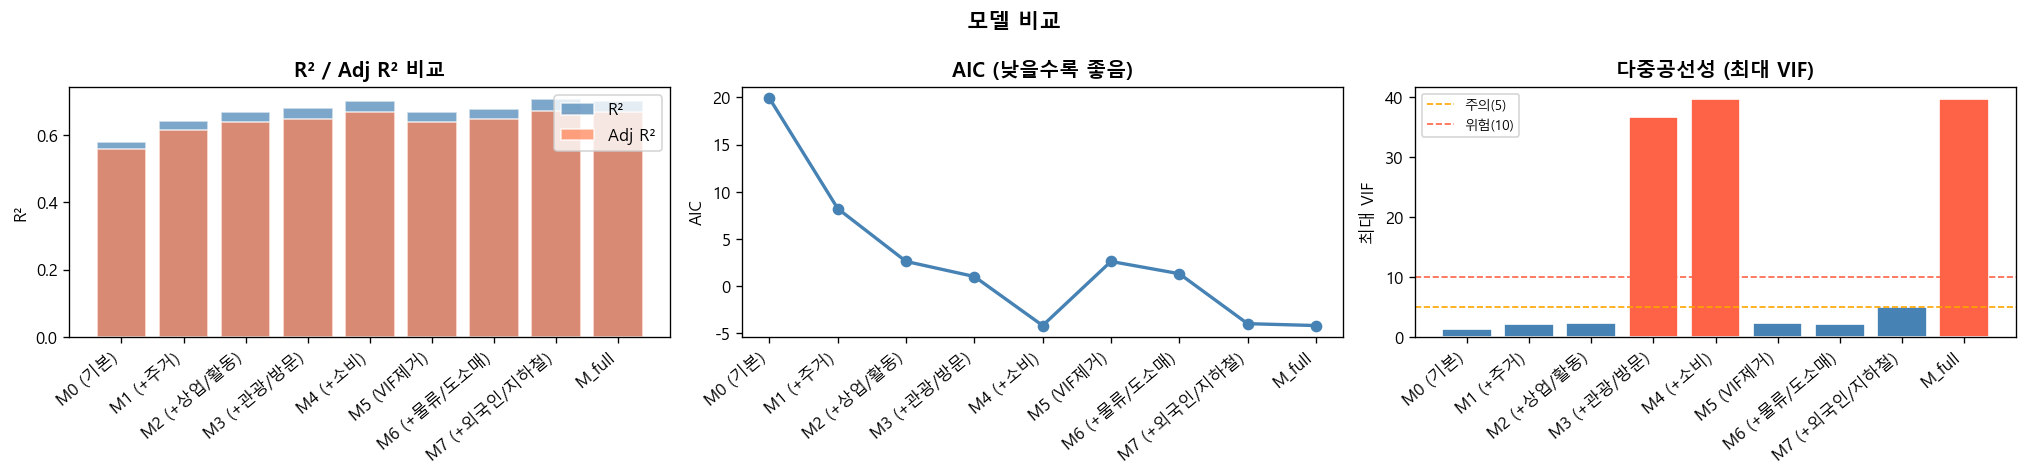

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
model_names = list(models.keys())
r2_vals     = cmp['R²'].values
adjr2_vals  = cmp['Adj R²'].values
aic_vals    = cmp['AIC'].values
maxvif_vals = cmp['max VIF'].values
x = range(len(model_names))

axes[0].bar(x, r2_vals,    color='steelblue', edgecolor='white', label='R²',    alpha=0.7)
axes[0].bar(x, adjr2_vals, color='coral',     edgecolor='white', label='Adj R²',alpha=0.7)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=40, ha='right')
axes[0].set_ylabel('R²'); axes[0].set_title('R² / Adj R² 비교', fontweight='bold')
axes[0].legend()

axes[1].plot(x, aic_vals, 'o-', color='steelblue', linewidth=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=40, ha='right')
axes[1].set_ylabel('AIC'); axes[1].set_title('AIC (낮을수록 좋음)', fontweight='bold')

bar_colors = ['tomato' if v > 10 else ('orange' if v > 5 else 'steelblue')
              for v in maxvif_vals]
axes[2].bar(x, maxvif_vals, color=bar_colors, edgecolor='white')
axes[2].axhline(5,  color='orange', linestyle='--', linewidth=1.0, label='주의(5)')
axes[2].axhline(10, color='tomato', linestyle='--', linewidth=1.0, label='위험(10)')
axes[2].set_xticks(x); axes[2].set_xticklabels(model_names, rotation=40, ha='right')
axes[2].set_ylabel('최대 VIF'); axes[2].set_title('다중공선성 (최대 VIF)', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('모델 비교', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 14. 최종 모델 선택


In [ ]:
coef_table = pd.DataFrame({
    "coef": m7.params,
    "pvalue": m7.pvalues,
    "ci_low": m7.conf_int()[0],
    "ci_high": m7.conf_int()[1]
})

coef_table["sig"] = coef_table["pvalue"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "." if p < 0.1 else "n.s."
)

coef_table

,coef,pvalue,ci_low,ci_high,sig
Intercept,11.815867,7.251613e-126,11.718380,11.913354,***
C(year)[T.2021],0.006014,9.258339e-01,-0.122009,0.134036,n.s.
C(year)[T.2022],0.040191,5.614775e-01,-0.096841,0.177223,n.s.
C(year)[T.2023],0.046693,5.417134e-01,-0.104777,0.198162,n.s.
living_pop_std,0.215526,4.409826e-05,0.115909,0.315144,***
food_accom_std,0.212150,1.946421e-08,0.143930,0.280371,***
elderly_std,-0.072615,4.675443e-02,-0.144164,-0.001066,*
single_hh_std,0.103788,1.518148e-03,0.040784,0.166792,**
retail_per_pop_std,-0.088925,2.535238e-03,-0.145781,-0.032069,**
foreigner_ratio_std,0.008372,8.374698e-01,-0.072499,0.089244,n.s.


In [ ]:
calc_vif(df, VARS_M7)

,변수,VIF,판정
0,생활인구 일평균,4.94,✓<5
1,음식숙박업 수,2.28,✓<5
2,고령인구 비율,1.95,✓<5
3,1인가구 비율,1.98,✓<5
4,도소매업 사업체/인구,1.63,✓<5
5,외국인 생활인구 비율,3.19,✓<5
6,log_subway_passenger_std,3.15,✓<5
7,대형사업체(100인+)/인구,2.05,✓<5


## 외국인 비율이 유의하지 않으므로 이를 제외한 모델을 만들어 비교

In [ ]:
VARS_M7_REDUCED = [
    v for v in VARS_M7
    if v != 'foreigner_ratio_std'
]

m7_reduced = fit_model(
    'M7-reduced: 외국인비율 제외',
    VARS_M7_REDUCED
)

 M7-reduced: 외국인비율 제외
  R²=0.7066  Adj R²=0.6736  F p=1.054e-19  CondNum=7.5

  생활인구 일평균                coef=+0.2114  p=0.0000  ***
  음식숙박업 수                 coef=+0.2114  p=0.0000  ***
  고령인구 비율                 coef=-0.0758  p=0.0218  *
  1인가구 비율                 coef=+0.1068  p=0.0002  ***
  도소매업 사업체/인구             coef=-0.0866  p=0.0013  **
  log_subway_passenger_std  coef=-0.0734  p=0.0741  n.s.
  대형사업체(100인+)/인구         coef=+0.1206  p=0.0002  ***

                      변수  VIF  판정
                생활인구 일평균 4.19 ✓<5
                 음식숙박업 수 2.27 ✓<5
                 고령인구 비율 1.64 ✓<5
                 1인가구 비율 1.51 ✓<5
             도소매업 사업체/인구 1.37 ✓<5
log_subway_passenger_std 3.14 ✓<5
         대형사업체(100인+)/인구 1.94 ✓<5



In [ ]:

BEST_MODEL = m7_reduced
BEST_VARS  = VARS_M7_REDUCED
BEST_LABEL = 'M7 (+외국인/지하철/대형사업체:외국인비율 제외)'
# ──────────────────────────────────────────────────────────────────

fitted    = BEST_MODEL.fittedvalues.values
residuals = BEST_MODEL.resid.values

print('선택 모델:', BEST_LABEL)
print('R²=' + f'{BEST_MODEL.rsquared:.4f}' +
      '  Adj R²=' + f'{BEST_MODEL.rsquared_adj:.4f}')
print('CondNum=' + f'{BEST_MODEL.condition_number:.1f}')
print()
print(BEST_MODEL.summary2())

선택 모델: M7 (+외국인/지하철/대형사업체:외국인비율 제외)
R²=0.7066  Adj R²=0.6736
CondNum=7.5

                     Results: Ordinary least squares
Model:                  OLS                Adj. R-squared:       0.674   
Dependent Variable:     log_waste          AIC:                  -5.9764 
Date:                   2026-05-02 01:37   BIC:                  22.6805 
No. Observations:       100                Log-Likelihood:       13.988  
Df Model:               10                 F-statistic:          21.43   
Df Residuals:           89                 Prob (F-statistic):   1.05e-19
R-squared:              0.707              Scale:                0.049732
-------------------------------------------------------------------------
                          Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
-------------------------------------------------------------------------
Intercept                11.8151   0.0487 242.7805 0.0000 11.7184 11.9118
C(year)[T.2021]           0.0057   0.0641   0.0897 0.9287 -

## 15. 잔차 진단 (최종 모델)

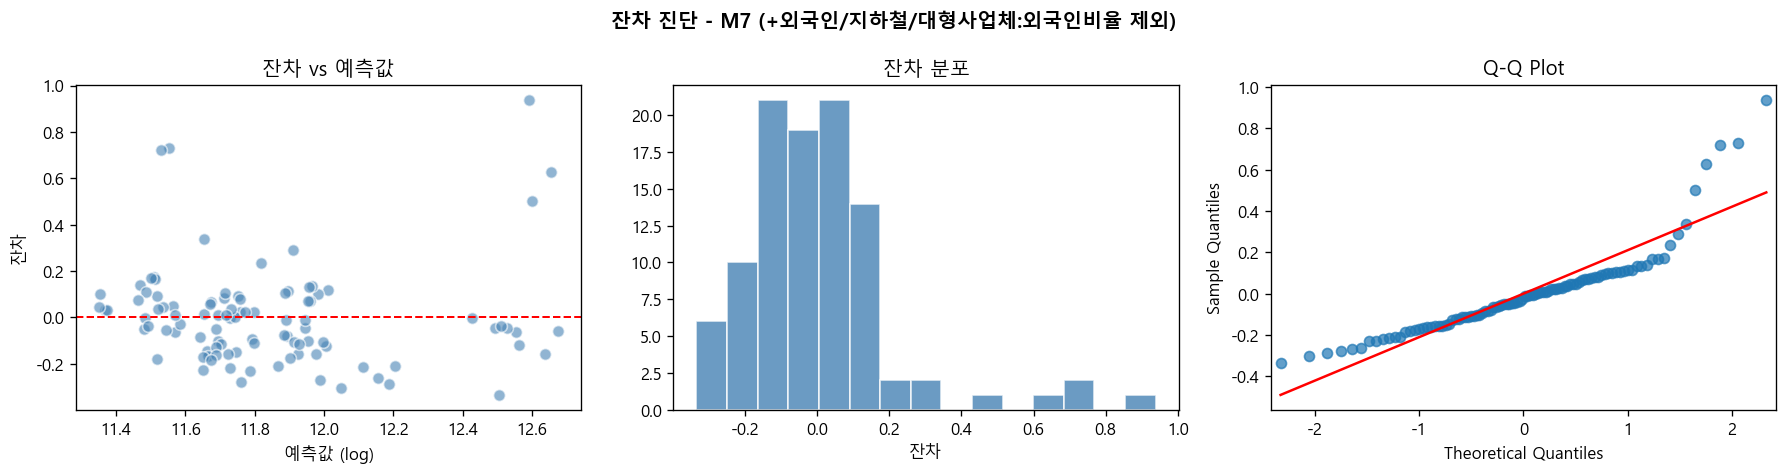

왜도=1.954  첨도=5.748


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted, residuals, alpha=0.6, s=50,
                color='steelblue', edgecolors='white')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('예측값 (log)'); axes[0].set_ylabel('잔차')
axes[0].set_title('잔차 vs 예측값')

axes[1].hist(residuals, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('잔차'); axes[1].set_title('잔차 분포')

sm.qqplot(residuals, line='s', ax=axes[2], alpha=0.7)
axes[2].set_title('Q-Q Plot')

plt.suptitle('잔차 진단 - ' + BEST_LABEL, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('왜도=' + f'{pd.Series(residuals).skew():.3f}' +
      '  첨도=' + f'{pd.Series(residuals).kurt():.3f}')

## 16. 이상치 진단 (Cook's Distance)

이상치: 5개 / 100개
 year  gu  waste_total  std_resid  cooks_d
 2021 강서구       751795   4.588854 0.360270
 2022 강서구       585756   3.086673 0.177636
 2022 용산구       216363   3.447819 0.112630
 2023 용산구       208742   3.392778 0.108897
 2023 강서구       490315   2.457515 0.106509


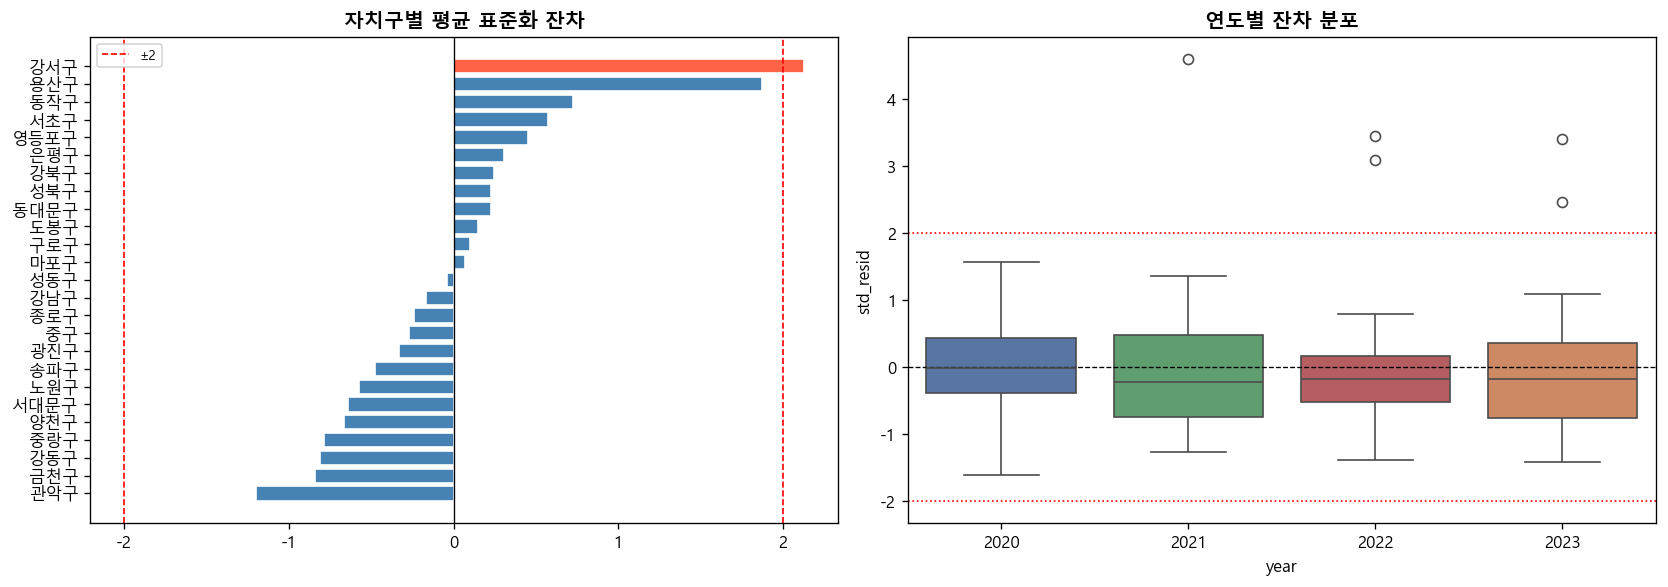

In [ ]:
influence  = BEST_MODEL.get_influence()
std_resid  = influence.resid_studentized_internal
cooks_d    = influence.cooks_distance[0]
thresh_cd  = 4 / len(df)

df_diag = df[['year','gu','waste_total']].copy()
df_diag['fitted']    = fitted
df_diag['std_resid'] = std_resid
df_diag['cooks_d']   = cooks_d

outliers = df_diag[
    (df_diag['std_resid'].abs() > 2) | (df_diag['cooks_d'] > thresh_cd)
].sort_values('cooks_d', ascending=False)

print('이상치: ' + str(len(outliers)) + '개 / ' + str(len(df)) + '개')
print(outliers[['year','gu','waste_total','std_resid','cooks_d']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gu_std = df_diag.groupby('gu')['std_resid'].mean().sort_values()
bar_c  = ['tomato' if abs(v) > 2 else 'steelblue' for v in gu_std.values]
axes[0].barh(gu_std.index, gu_std.values, color=bar_c, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline( 2, color='red', linestyle='--', linewidth=1.0, label='±2')
axes[0].axvline(-2, color='red', linestyle='--', linewidth=1.0)
axes[0].set_title('자치구별 평균 표준화 잔차', fontweight='bold')
axes[0].legend(fontsize=8)

sns.boxplot(data=df_diag, x='year', y='std_resid', ax=axes[1],
            palette={str(y): c for y, c in
                     zip([2020,2021,2022,2023],
                         ['#4C72B0','#55A868','#C44E52','#DD8452'])})
axes[1].axhline(0,  color='black', linewidth=0.8, linestyle='--')
axes[1].axhline( 2, color='red', linestyle=':', linewidth=1.0)
axes[1].axhline(-2, color='red', linestyle=':', linewidth=1.0)
axes[1].set_title('연도별 잔차 분포', fontweight='bold')
plt.tight_layout(); plt.show()

## 17. 조정지표 산출

> **조정지표 = 실제 발생량(톤) / exp(예측_log) × 100**

In [ ]:
df['pred_waste_ton']  = np.exp(fitted)
df['residual']        = residuals
df['adjusted_index']  = (df['waste_total'] / df['pred_waste_ton'] * 100).round(2)

idx_by_gu = df.groupby('gu')['adjusted_index'].mean().round(2).sort_values(ascending=False)

print('=== 자치구별 평균 조정지표 ===')
for gu, val in idx_by_gu.items():
    bar  = '▓' * int(abs(val - 100) / 2)
    flag = ' ↑ 초과' if val > 105 else (' ↓ 절약' if val < 95 else '')
    print('  ' + f'{gu:5s}' + '  ' + f'{val:6.1f}' + '  ' + bar + flag)

=== 자치구별 평균 조정지표 ===
  강서구     169.9  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓ ↑ 초과
  용산구     156.9  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓ ↑ 초과
  동작구     116.8  ▓▓▓▓▓▓▓▓ ↑ 초과
  서초구     112.9  ▓▓▓▓▓▓ ↑ 초과
  영등포구    109.3  ▓▓▓▓ ↑ 초과
  은평구     106.8  ▓▓▓ ↑ 초과
  동대문구    106.7  ▓▓▓ ↑ 초과
  강북구     105.3  ▓▓ ↑ 초과
  성북구     105.2  ▓▓ ↑ 초과
  도봉구     103.5  ▓
  구로구     103.1  ▓
  마포구     102.9  ▓
  성동구      99.2  
  강남구      96.7  ▓
  종로구      95.3  ▓▓
  중구       95.1  ▓▓
  광진구      93.8  ▓▓▓ ↓ 절약
  송파구      90.5  ▓▓▓▓ ↓ 절약
  노원구      88.4  ▓▓▓▓▓ ↓ 절약
  양천구      87.3  ▓▓▓▓▓▓ ↓ 절약
  서대문구     87.1  ▓▓▓▓▓▓ ↓ 절약
  중랑구      85.0  ▓▓▓▓▓▓▓ ↓ 절약
  강동구      84.4  ▓▓▓▓▓▓▓ ↓ 절약
  금천구      84.2  ▓▓▓▓▓▓▓ ↓ 절약
  관악구      78.4  ▓▓▓▓▓▓▓▓▓▓ ↓ 절약


## 18. 조정지표 시각화

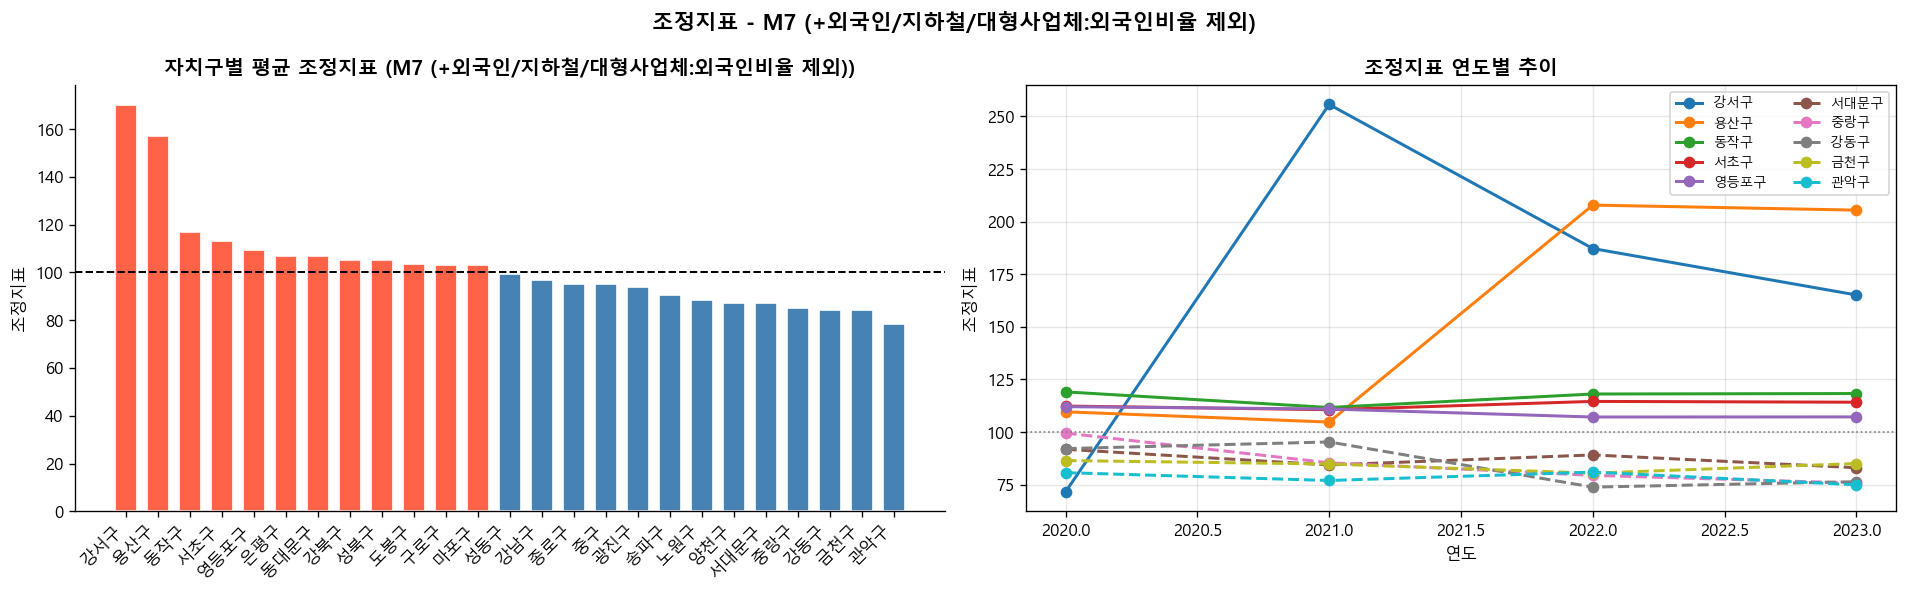

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = ['tomato' if v > 100 else 'steelblue' for v in idx_by_gu.values]
axes[0].bar(idx_by_gu.index, idx_by_gu.values,
            color=bar_colors, edgecolor='white', width=0.7)
axes[0].axhline(100, color='black', linewidth=1.2, linestyle='--')
axes[0].set_xticklabels(idx_by_gu.index, rotation=45, ha='right')
axes[0].set_ylabel('조정지표')
axes[0].set_title('자치구별 평균 조정지표 (' + BEST_LABEL + ')', fontweight='bold')
for sp in ['top','right']: axes[0].spines[sp].set_visible(False)

top5    = idx_by_gu.head(5).index.tolist()
bottom5 = idx_by_gu.tail(5).index.tolist()
pivot   = df[df['gu'].isin(top5+bottom5)].pivot(
    index='year', columns='gu', values='adjusted_index'
)
for gu in top5+bottom5:
    ls = '-' if gu in top5 else '--'
    axes[1].plot(pivot.index, pivot[gu], marker='o',
                 linewidth=1.8, linestyle=ls, label=gu)
axes[1].axhline(100, color='gray', linewidth=1, linestyle=':')
axes[1].set_xlabel('연도'); axes[1].set_ylabel('조정지표')
axes[1].set_title('조정지표 연도별 추이', fontweight='bold')
axes[1].legend(ncol=2, fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('조정지표 - ' + BEST_LABEL, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 19. 결과 저장

In [ ]:
out_cols = ['year','gu','waste_total','pred_waste_ton','residual','adjusted_index']
df_out = df[out_cols].sort_values(['year','gu']).reset_index(drop=True)
df_out.to_csv(FINAL / 'adjusted_index_by_gu_year.csv',
              index=False, encoding='utf-8-sig')
print('저장 완료:', df_out.shape)

df23 = df_out[df_out['year']==2023].sort_values('adjusted_index', ascending=False)
print()
print('[2023] 상위 5구 (초과 발생):')
print(df23.head(5)[['gu','waste_total','pred_waste_ton','adjusted_index']].to_string(index=False))
print()
print('[2023] 하위 5구 (절약 발생):')
print(df23.tail(5)[['gu','waste_total','pred_waste_ton','adjusted_index']].to_string(index=False))

저장 완료: (100, 6)

[2023] 상위 5구 (초과 발생):
 gu  waste_total  pred_waste_ton  adjusted_index
용산구       208742   101598.259060          205.46
강서구       490315   296930.820260          165.13
구로구       171610   135858.969057          126.31
동작구       116719    98671.088847          118.29
서초구       178090   155986.070081          114.17

[2023] 하위 5구 (절약 발생):
  gu  waste_total  pred_waste_ton  adjusted_index
서대문구        97594   117536.360698           83.03
 양천구       115678   142490.357218           81.18
 강동구       122793   160720.202067           76.40
 중랑구        96847   127905.587915           75.72
 관악구       146875   196100.902827           74.90
